Number of countries: 225
Total population: 7354877579
R0: 5
beta: 0.2
mu: 0.04
Number of valid edges: 2317

Selected seed ID: 3
   ID           Label  Population
3   3  American Samoa       53466
Completed 50/50

Saved:
country_monte_carlo_id_seed_results.csv
country_monte_carlo_id_seed_histories.csv
country_monte_carlo_id_seed_summary.csv


,seed_country_id,initial_prevalence,R0,beta,mu,num_simulations,mean_final_attack_rate,std_final_attack_rate,mean_peak_infected,mean_peak_infected_rate,mean_countries_reached_max,std_countries_reached_max,mean_steps_run
0,3,0.001,5,0.2,0.04,50,0.991995,0.000176,2.563731e+09,0.348576,225.0,0.0,365.0


,seed_index,seed_id,seed_country,seed_population,initial_prevalence,initial_infected,R0,beta,mu,dt,...,steps_run,final_susceptible,final_infected,final_recovered,final_attack_rate,peak_infected,peak_infected_rate,countries_reached_final,countries_reached_max,simulation
0,3,3,American Samoa,53466,0.001,53,5.0,0.2,0.04,1.0,...,365,46489018,13070635,7295317926,0.991902,2549800286,0.346682,225,225,0
1,3,3,American Samoa,53466,0.001,53,5.0,0.2,0.04,1.0,...,365,46417623,11197535,7297262421,0.992166,2618111174,0.355969,225,225,1
2,3,3,American Samoa,53466,0.001,53,5.0,0.2,0.04,1.0,...,365,46348462,9362508,7299166609,0.992425,2616059285,0.355690,225,225,2
3,3,3,American Samoa,53466,0.001,53,5.0,0.2,0.04,1.0,...,365,46477502,12514665,7295885412,0.991979,2333590923,0.317285,225,225,3
4,3,3,American Samoa,53466,0.001,53,5.0,0.2,0.04,1.0,...,365,46451719,12495928,7295929932,0.991985,2596465113,0.353026,225,225,4


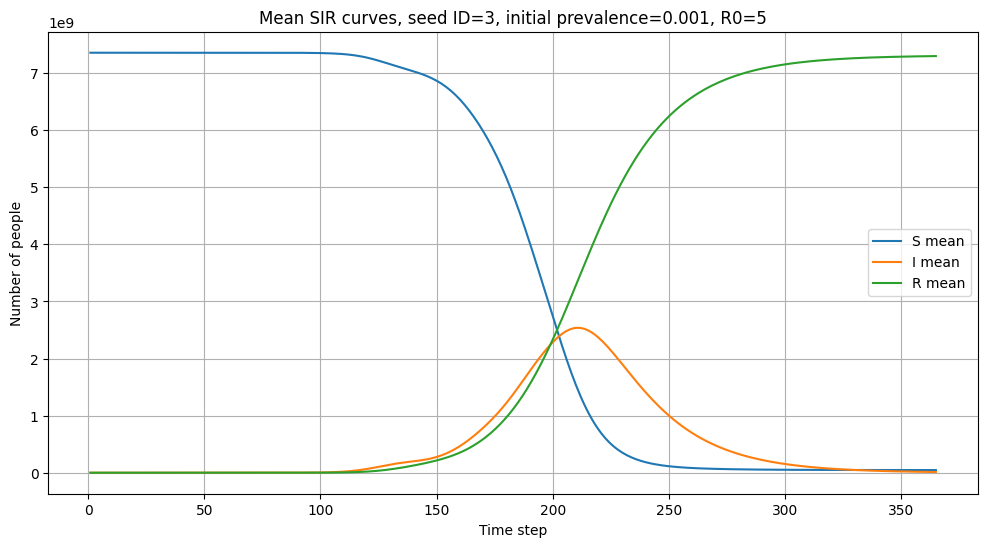

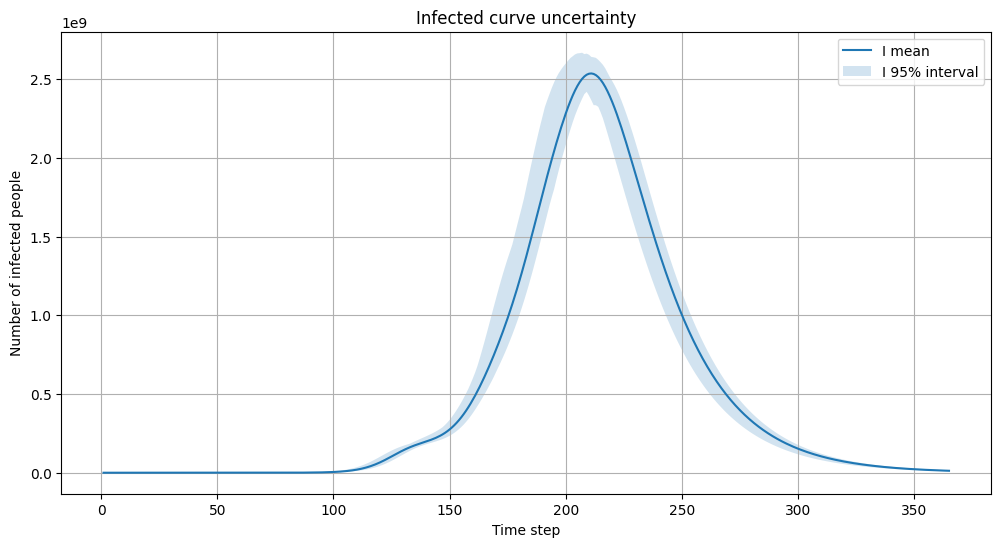

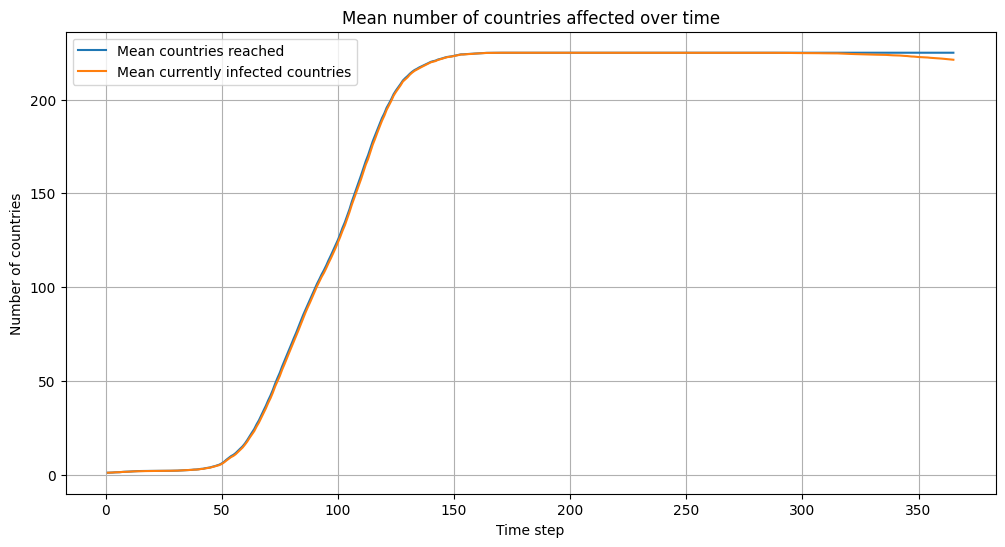

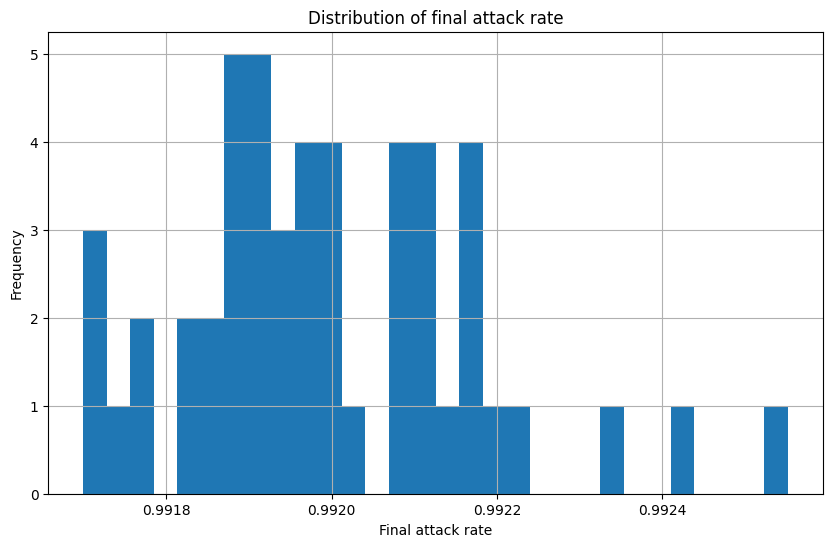

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path


# ============================================================
# 0. Configuration
# ============================================================

@dataclass(frozen=True)
class SimulationConfig:
    # File settings
    node_file: str = "nodelist_connected.csv"
    edge_file: str = "edgelist_symmetric.csv"
    weight_column: str = "Avg. Number of Routes"
    output_dir: str = "."

    # Travel settings
    passengers_per_route: int = 200

    # Simulation settings
    random_seed: int = 42
    dt: float = 1.0
    mu: float = 1 / 7
    r0: float = 2.0
    num_simulations: int = 500
    max_steps: int = 365

    # Initial outbreak settings
    seed_country_id: int = 0
    initial_prevalence: float = 1e-5

    # Step order: "local_then_travel" or "travel_then_local"
    step_order: str = "local_then_travel"

    @property
    def beta(self) -> float:
        return self.r0 * self.mu


# ============================================================
# 1. Data loading
# ============================================================

def load_nodes(node_file: str):
    nodes = pd.read_csv(node_file)

    nodes["ID"] = nodes["ID"].astype(int)
    nodes["Label"] = nodes["Label"].astype(str)
    nodes["Population"] = nodes["Population"].round().astype(np.int64)

    nodes = nodes[nodes["Population"] > 0].reset_index(drop=True)

    node_ids = nodes["ID"].to_numpy()
    country_names = nodes["Label"].to_numpy()
    population = nodes["Population"].to_numpy(dtype=np.int64)
    id_to_idx = {node_id: idx for idx, node_id in enumerate(node_ids)}

    return nodes, node_ids, country_names, population, id_to_idx


def load_edges(edge_file: str, weight_column: str, passengers_per_route: int, id_to_idx: dict):
    edges = pd.read_csv(edge_file)

    edges["Source"] = edges["Source"].astype(int)
    edges["Target"] = edges["Target"].astype(int)

    if weight_column not in edges.columns:
        raise ValueError(f"'{weight_column}' column not found in edge file.")

    edges[weight_column] = edges[weight_column].fillna(0).astype(float)

    valid_edges = []

    for _, row in edges.iterrows():
        source_id = int(row["Source"])
        target_id = int(row["Target"])
        weight = float(row[weight_column])

        if weight <= 0:
            continue
        if source_id not in id_to_idx or target_id not in id_to_idx:
            continue

        i = id_to_idx[source_id]
        j = id_to_idx[target_id]

        if i == j:
            continue

        passengers = int(round(weight * passengers_per_route))

        if passengers <= 0:
            continue

        # edge 한 줄을 양방향으로 해석
        valid_edges.append((i, j, passengers, weight))

    return valid_edges


# ============================================================
# 2. Initial outbreak
# ============================================================

def initialize_selected_outbreak(
    population,
    country_names,
    node_ids,
    seed_country_id,
    initial_prevalence,
):
    S = population.copy().astype(np.int64)
    I = np.zeros(len(population), dtype=np.int64)
    R = np.zeros(len(population), dtype=np.int64)

    matches = np.where(node_ids == seed_country_id)[0]

    if len(matches) == 0:
        raise ValueError(
            f"SEED_COUNTRY_ID {seed_country_id} not found in nodelist file."
        )

    seed_idx = int(matches[0])
    seed_population = int(population[seed_idx])

    initial_infected = int(round(seed_population * initial_prevalence))
    initial_infected = max(1, initial_infected)
    initial_infected = min(initial_infected, seed_population)

    I[seed_idx] = initial_infected
    S[seed_idx] -= initial_infected

    seed_info = {
        "seed_index": seed_idx,
        "seed_id": int(node_ids[seed_idx]),
        "seed_country": str(country_names[seed_idx]),
        "seed_population": seed_population,
        "initial_prevalence": float(initial_prevalence),
        "initial_infected": int(initial_infected),
    }

    return S, I, R, seed_info


# ============================================================
# 3. Simulation steps
# ============================================================

def local_reaction_step(S, I, R, population, beta, mu, dt, rng):
    p_infection = 1 - np.exp(-beta * I / population * dt)
    p_infection = np.clip(p_infection, 0.0, 1.0)

    p_recovery = 1 - np.exp(-mu * dt)
    p_recovery = np.clip(p_recovery, 0.0, 1.0)

    new_infections = rng.binomial(S, p_infection)
    new_recoveries = rng.binomial(I, p_recovery)

    S_next = S - new_infections
    I_next = I + new_infections - new_recoveries
    R_next = R + new_recoveries

    return S_next, I_next, R_next


def travel_seed_step(S, I, R, population, valid_edges, beta, dt, rng):
    imported_infectious_pressure = np.zeros(len(population), dtype=np.int64)

    for i, j, passengers, _ in valid_edges:
        Ni = int(population[i])
        Nj = int(population[j])

        if Ni <= 0 or Nj <= 0:
            continue

        p_inf_i = np.clip(I[i] / Ni, 0.0, 1.0)
        p_inf_j = np.clip(I[j] / Nj, 0.0, 1.0)

        infected_i_to_j = rng.binomial(passengers, p_inf_i)
        infected_j_to_i = rng.binomial(passengers, p_inf_j)

        imported_infectious_pressure[j] += infected_i_to_j
        imported_infectious_pressure[i] += infected_j_to_i

    p_imported_infection = 1 - np.exp(
        -beta * imported_infectious_pressure / population * dt
    )
    p_imported_infection = np.clip(p_imported_infection, 0.0, 1.0)

    new_imported_infections = rng.binomial(S, p_imported_infection)

    S_next = S - new_imported_infections
    I_next = I + new_imported_infections
    R_next = R.copy()

    return S_next, I_next, R_next, imported_infectious_pressure, new_imported_infections


# ============================================================
# 4. One simulation
# ============================================================

def run_one_simulation(population, country_names, node_ids, valid_edges, config: SimulationConfig, rng):
    S, I, R, seed_info = initialize_selected_outbreak(
        population=population,
        country_names=country_names,
        node_ids=node_ids,
        seed_country_id=config.seed_country_id,
        initial_prevalence=config.initial_prevalence,
    )

    history = []

    for step in range(config.max_steps):
        if config.step_order == "local_then_travel":
            S, I, R = local_reaction_step(
                S, I, R, population, config.beta, config.mu, config.dt, rng
            )
            S, I, R, imported_pressure, imported_new = travel_seed_step(
                S, I, R, population, valid_edges, config.beta, config.dt, rng
            )

        elif config.step_order == "travel_then_local":
            S, I, R, imported_pressure, imported_new = travel_seed_step(
                S, I, R, population, valid_edges, config.beta, config.dt, rng
            )
            S, I, R = local_reaction_step(
                S, I, R, population, config.beta, config.mu, config.dt, rng
            )

        else:
            raise ValueError("step_order must be 'local_then_travel' or 'travel_then_local'.")

        total_S = int(S.sum())
        total_I = int(I.sum())
        total_R = int(R.sum())

        history.append({
            "step": step + 1,
            "S_total": total_S,
            "I_total": total_I,
            "R_total": total_R,
            "countries_reached": int(np.sum((I + R) > 0)),
            "countries_currently_infected": int(np.sum(I > 0)),
            "imported_infectious_pressure_total": int(imported_pressure.sum()),
            "new_imported_infections_total": int(imported_new.sum()),
        })

        if total_I == 0:
            break

    history_df = pd.DataFrame(history)
    total_population = population.sum()

    result = {
        **seed_info,
        "R0": float(config.r0),
        "beta": float(config.beta),
        "mu": float(config.mu),
        "dt": float(config.dt),
        "step_order": config.step_order,
        "steps_run": int(len(history_df)),
        "final_susceptible": int(S.sum()),
        "final_infected": int(I.sum()),
        "final_recovered": int(R.sum()),
        "final_attack_rate": float(R.sum() / total_population),
        "peak_infected": int(history_df["I_total"].max()) if len(history_df) else 0,
        "peak_infected_rate": float(history_df["I_total"].max() / total_population) if len(history_df) else 0,
        "countries_reached_final": int(np.sum((I + R) > 0)),
        "countries_reached_max": int(history_df["countries_reached"].max()) if len(history_df) else 0,
    }

    return result, history_df


# ============================================================
# 5. Monte Carlo runner
# ============================================================

def run_monte_carlo(population, country_names, node_ids, valid_edges, config: SimulationConfig):
    rng = np.random.default_rng(config.random_seed)

    all_results = []
    all_histories = []

    for sim in range(config.num_simulations):
        result, history_df = run_one_simulation(
            population=population,
            country_names=country_names,
            node_ids=node_ids,
            valid_edges=valid_edges,
            config=config,
            rng=rng,
        )

        result["simulation"] = sim
        all_results.append(result)

        history_df["simulation"] = sim
        all_histories.append(history_df)

        if (sim + 1) % 50 == 0:
            print(f"Completed {sim + 1}/{config.num_simulations}")

    results_df = pd.DataFrame(all_results)
    histories_df = pd.concat(all_histories, ignore_index=True)

    return results_df, histories_df


# ============================================================
# 6. Summary and S/I/R aggregation
# ============================================================

def make_summary(results_df: pd.DataFrame, config: SimulationConfig):
    summary = {
        "seed_country_id": config.seed_country_id,
        "initial_prevalence": config.initial_prevalence,
        "R0": config.r0,
        "beta": config.beta,
        "mu": config.mu,
        "num_simulations": config.num_simulations,
        "mean_final_attack_rate": results_df["final_attack_rate"].mean(),
        "std_final_attack_rate": results_df["final_attack_rate"].std(),
        "mean_peak_infected": results_df["peak_infected"].mean(),
        "mean_peak_infected_rate": results_df["peak_infected_rate"].mean(),
        "mean_countries_reached_max": results_df["countries_reached_max"].mean(),
        "std_countries_reached_max": results_df["countries_reached_max"].std(),
        "mean_steps_run": results_df["steps_run"].mean(),
    }

    return pd.DataFrame([summary])


def make_sir_summary(histories_df: pd.DataFrame, config: SimulationConfig):
    full_steps = pd.DataFrame({
        "step": np.arange(1, config.max_steps + 1)
    })

    padded_histories = []

    for sim in range(config.num_simulations):
        h = histories_df[histories_df["simulation"] == sim].copy()

        if len(h) == 0:
            continue

        h = full_steps.merge(h, on="step", how="left")
        h["simulation"] = sim

        h["S_total"] = h["S_total"].ffill()
        h["I_total"] = h["I_total"].fillna(0)
        h["R_total"] = h["R_total"].ffill()

        h["countries_reached"] = h["countries_reached"].ffill()
        h["countries_currently_infected"] = h["countries_currently_infected"].fillna(0)

        padded_histories.append(h)

    padded_histories_df = pd.concat(padded_histories, ignore_index=True)

    return (
        padded_histories_df
        .groupby("step")
        .agg(
            S_mean=("S_total", "mean"),
            I_mean=("I_total", "mean"),
            R_mean=("R_total", "mean"),
            I_lower=("I_total", lambda x: np.percentile(x, 2.5)),
            I_upper=("I_total", lambda x: np.percentile(x, 97.5)),
            countries_reached_mean=("countries_reached", "mean"),
            countries_currently_infected_mean=("countries_currently_infected", "mean"),
        )
        .reset_index()
    )


# ============================================================
# 7. Save and plot
# ============================================================

def save_outputs(results_df, histories_df, summary_df, output_dir: str):
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    results_file = output_path / "country_monte_carlo_id_seed_results.csv"
    histories_file = output_path / "country_monte_carlo_id_seed_histories.csv"
    summary_file = output_path / "country_monte_carlo_id_seed_summary.csv"

    results_df.to_csv(results_file, index=False)
    histories_df.to_csv(histories_file, index=False)
    summary_df.to_csv(summary_file, index=False)

    print("\nSaved:")
    print(results_file)
    print(histories_file)
    print(summary_file)


def plot_results(sir_summary: pd.DataFrame, results_df: pd.DataFrame, config: SimulationConfig):
    plt.figure(figsize=(12, 6))
    plt.plot(sir_summary["step"], sir_summary["S_mean"], label="S mean")
    plt.plot(sir_summary["step"], sir_summary["I_mean"], label="I mean")
    plt.plot(sir_summary["step"], sir_summary["R_mean"], label="R mean")
    plt.xlabel("Time step")
    plt.ylabel("Number of people")
    plt.title(
        f"Mean SIR curves, seed ID={config.seed_country_id}, "
        f"initial prevalence={config.initial_prevalence}, R0={config.r0}"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(sir_summary["step"], sir_summary["I_mean"], label="I mean")
    plt.fill_between(
        sir_summary["step"],
        sir_summary["I_lower"],
        sir_summary["I_upper"],
        alpha=0.2,
        label="I 95% interval",
    )
    plt.xlabel("Time step")
    plt.ylabel("Number of infected people")
    plt.title("Infected curve uncertainty")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(
        sir_summary["step"],
        sir_summary["countries_reached_mean"],
        label="Mean countries reached",
    )
    plt.plot(
        sir_summary["step"],
        sir_summary["countries_currently_infected_mean"],
        label="Mean currently infected countries",
    )
    plt.xlabel("Time step")
    plt.ylabel("Number of countries")
    plt.title("Mean number of countries affected over time")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(results_df["final_attack_rate"], bins=30)
    plt.xlabel("Final attack rate")
    plt.ylabel("Frequency")
    plt.title("Distribution of final attack rate")
    plt.grid(True)
    plt.show()


# ============================================================
# 8. Main
# ============================================================

def main():
    config = SimulationConfig(
        node_file="./data/nodelist_connected.csv",
        edge_file="./data/edgelist_symmetric.csv",
        weight_column="Avg. Number of Routes",
        output_dir=".",
        passengers_per_route=200,
        random_seed=42,
        dt=1.0,
        mu=0.04,
        r0=5,
        num_simulations=50,
        max_steps=365,
        seed_country_id=3,
        initial_prevalence=1e-3,
        step_order="local_then_travel",
    )

    nodes, node_ids, country_names, population, id_to_idx = load_nodes(config.node_file)
    valid_edges = load_edges(
        edge_file=config.edge_file,
        weight_column=config.weight_column,
        passengers_per_route=config.passengers_per_route,
        id_to_idx=id_to_idx,
    )

    print("Number of countries:", len(nodes))
    print("Total population:", int(population.sum()))
    print("R0:", config.r0)
    print("beta:", config.beta)
    print("mu:", config.mu)
    print("Number of valid edges:", len(valid_edges))

    print("\nSelected seed ID:", config.seed_country_id)
    print(nodes[nodes["ID"] == config.seed_country_id][["ID", "Label", "Population"]])

    results_df, histories_df = run_monte_carlo(
        population=population,
        country_names=country_names,
        node_ids=node_ids,
        valid_edges=valid_edges,
        config=config,
    )

    summary_df = make_summary(results_df, config)
    sir_summary = make_sir_summary(histories_df, config)

    save_outputs(results_df, histories_df, summary_df, config.output_dir)

    display(summary_df)
    display(results_df.head())

    plot_results(sir_summary, results_df, config)


if __name__ == "__main__":
    main()
